# NYC Weather and Traffic Delay Prediction

This notebook builds an API-based data pipeline that combines NYC traffic volume data with weather data, stores the cleaned dataset in MySQL, explores congestion patterns, trains weather-aware delay-risk models, and exports Tableau-ready dashboard tables.


## 1. Environment Setup

Install dependencies if needed, then import the libraries used for API ingestion, data cleaning, visualization, modeling, MySQL storage, and Tableau exports.


In [150]:
# Optional: run once if these packages are missing from your notebook kernel.
%pip install openmeteo-requests requests-cache retry-requests


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [151]:
# Optional: run once if these packages are missing from your notebook kernel.
%pip install sqlalchemy pymysql python-dotenv


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Weather API Ingestion

Pull historical weather observations from the Open-Meteo API for New York City. These records become the weather side of the traffic-delay analysis.


In [152]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 40.73061,
	"longitude": -73.935242,
	"start_date": "2020-01-01",
	"end_date": "2025-12-31",
	"daily": [
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",   
    "sunrise",
    "sunset"
],
	"hourly": ["temperature_2m", "relative_humidity_2m", "dew_point_2m", "apparent_temperature", "precipitation", "rain", "snowfall", "snow_depth", "wind_speed_10m"],
	"timezone": "auto",
	"temperature_unit": "fahrenheit",
	"wind_speed_unit": "mph",
	"precipitation_unit": "inch",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_dew_point_2m = hourly.Variables(2).ValuesAsNumpy()
hourly_apparent_temperature = hourly.Variables(3).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(4).ValuesAsNumpy()
hourly_rain = hourly.Variables(5).ValuesAsNumpy()
hourly_snowfall = hourly.Variables(6).ValuesAsNumpy()
hourly_snow_depth = hourly.Variables(7).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(8).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["dew_point_2m"] = hourly_dew_point_2m
hourly_data["apparent_temperature"] = hourly_apparent_temperature
hourly_data["precipitation"] = hourly_precipitation
hourly_data["rain"] = hourly_rain
hourly_data["snowfall"] = hourly_snowfall
hourly_data["snow_depth"] = hourly_snow_depth
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m

hourly_dataframe = pd.DataFrame(data = hourly_data)

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()

daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
daily_temperature_2m_max = daily.Variables(1).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(2).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(3).ValuesAsNumpy()   # ✅ ADD THIS
daily_sunrise = daily.Variables(4).ValuesInt64AsNumpy()
daily_sunset = daily.Variables(5).ValuesInt64AsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["precipitation"] = daily_precipitation_sum
daily_data["sunrise"] = daily_sunrise
daily_data["sunset"] = daily_sunset
daily_dataframe = pd.DataFrame(data = daily_data)

hourly_dataframe.head()

Coordinates: 40.738136291503906°N -73.91488647460938°E
Elevation: 14.0 m asl
Timezone: b'America/New_York'b'GMT-4'
Timezone difference to GMT+0: -14400s


,date,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,wind_speed_10m
0,2020-01-01 00:00:00+00:00,39.829998,79.699532,34.070000,32.075100,0.0,0.0,0.0,0.0,10.088845
1,2020-01-01 01:00:00+00:00,38.209999,75.076363,31.010000,29.407892,0.0,0.0,0.0,0.0,11.428421
2,2020-01-01 02:00:00+00:00,35.779999,77.071312,29.299999,26.927099,0.0,0.0,0.0,0.0,10.963583
3,2020-01-01 03:00:00+00:00,34.790001,78.990501,28.940001,26.067801,0.0,0.0,0.0,0.0,10.535296
4,2020-01-01 04:00:00+00:00,34.160000,77.779877,27.950001,24.650108,0.0,0.0,0.0,0.0,12.081872


## 3. Traffic API Ingestion

Pull NYC traffic volume records directly from the NYC Open Data API. The project uses API ingestion instead of CSV files.


In [153]:
import requests
import pandas as pd

url = "https://data.cityofnewyork.us/resource/7ym2-wayt.json?$limit=50000"

response = requests.get(url)
data = response.json()

df_traffic = pd.DataFrame(data)

print(df_traffic.head())
print(df_traffic.columns)

  requestid    boro    yr  m  d hh  mm vol segmentid  \
0     12512  Queens  2013  3  7  4  15   5     55135   
1     12512  Queens  2013  3  7  4  30   8     55135   
2     12512  Queens  2013  3  7  4  45   8     55135   
3     12512  Queens  2013  3  7  5   0   7     55135   
4     12512  Queens  2013  3  7  5  15   9     55135   

                      wktgeom  street     fromst           tost direction  
0  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
1  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
2  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
3  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
4  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
Index(['requestid', 'boro', 'yr', 'm', 'd', 'hh', 'mm', 'vol', 'segmentid',
       'wktgeom', 'street', 'fromst', 'tost', 'direction'],
      dtype='str')


## 4. Clean, Align, and Merge

Standardize date and hour fields, merge traffic and weather records, and create the final modeling table.


In [154]:
hourly_dataframe["date"] = pd.to_datetime(hourly_dataframe["date"])
hourly_dataframe["date"] = hourly_dataframe["date"].dt.tz_localize(None)

hourly_dataframe["date_only"] = hourly_dataframe["date"].dt.date
hourly_dataframe["hour"] = hourly_dataframe["date"].dt.hour

In [155]:
df_traffic["date"] = pd.to_datetime(
    df_traffic["yr"].astype(str) + "-" +
    df_traffic["m"].astype(str) + "-" +
    df_traffic["d"].astype(str)
)

df_traffic["hour"] = df_traffic["hh"].astype(int)
df_traffic["vol"] = pd.to_numeric(df_traffic["vol"], errors="coerce")

df_traffic = df_traffic.dropna(subset=["date", "hour", "vol"])

In [156]:
df_traffic["date"] = pd.to_datetime(df_traffic["date"])
hourly_dataframe["date_only"] = pd.to_datetime(hourly_dataframe["date"].dt.date)

In [157]:
df_merged = pd.merge(
    df_traffic,
    hourly_dataframe,
    left_on=["date", "hour"],
    right_on=["date_only", "hour"],
    how="inner"
)

In [158]:
df_merged = df_merged.rename(columns={"date_x": "date"})

In [159]:
df_final = df_merged[[
    "date",
    "hour",
    "boro",
    "street",
    "fromst",
    "tost",
    "direction",
    "vol",
    "temperature_2m",
    "precipitation"
]].copy()

df_final = df_final.dropna()

In [160]:
# Preview the merged dataset before writing to MySQL.
display(df_final.head())
print(f"Final rows: {len(df_final):,}")


,date,hour,boro,street,fromst,tost,direction,vol,temperature_2m,precipitation
0,2023-11-15,20,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,20,45.139999,0.0
1,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,15,45.950001,0.0
2,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,26,45.950001,0.0
3,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,23,45.950001,0.0
4,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,13,45.950001,0.0


Final rows: 8,776


## 5. MySQL Storage

Create/connect to the MySQL database and write the API-generated final table. This keeps Tableau and downstream analysis connected to database tables rather than local CSV files.


In [161]:
import os
from urllib.parse import quote_plus
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

load_dotenv()

MYSQL_USER = os.getenv("MYSQL_USER", "root")
MYSQL_PASSWORD = quote_plus(os.getenv("MYSQL_PASSWORD", "your_password"))
MYSQL_HOST = os.getenv("MYSQL_HOST", "localhost")
MYSQL_PORT = os.getenv("MYSQL_PORT", "3306")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE", "weather_traffic")

# Connect to MySQL server, not a specific database yet
server_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/",
    pool_pre_ping=True
)

with server_engine.connect() as conn:
    conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {MYSQL_DATABASE}"))
    conn.commit()

# Now connect to the database you created
engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}",
    pool_pre_ping=True
)



In [162]:
df_final.to_sql(
    "weather_traffic_full",
    con=engine,
    if_exists="replace",
    index=False
)

8776

## 6. Exploratory Data Analysis

Explore data quality, traffic patterns, borough differences, weather relationships, and temporal trends before modeling.


In [163]:
import matplotlib.pyplot as plt

eda_df = df_final.copy()
eda_df["date"] = pd.to_datetime(eda_df["date"])
eda_df["vol"] = pd.to_numeric(eda_df["vol"], errors="coerce")
eda_df["temperature_2m"] = pd.to_numeric(eda_df["temperature_2m"], errors="coerce")
eda_df["precipitation"] = pd.to_numeric(eda_df["precipitation"], errors="coerce")
eda_df["day_of_week"] = eda_df["date"].dt.day_name()
eda_df["month"] = eda_df["date"].dt.to_period("M").astype(str)
eda_df["is_raining"] = eda_df["precipitation"] > 0

print(f"Rows: {eda_df.shape[0]:,}")
print(f"Columns: {eda_df.shape[1]:,}")
print(f"Date range: {eda_df['date'].min().date()} to {eda_df['date'].max().date()}")
display(eda_df.head())

Rows: 8,776
Columns: 13
Date range: 2020-01-26 to 2024-06-07


,date,hour,boro,street,fromst,tost,direction,vol,temperature_2m,precipitation,day_of_week,month,is_raining
0,2023-11-15,20,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,20,45.139999,0.0,Wednesday,2023-11,False
1,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,15,45.950001,0.0,Wednesday,2023-11,False
2,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,26,45.950001,0.0,Wednesday,2023-11,False
3,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,23,45.950001,0.0,Wednesday,2023-11,False
4,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,13,45.950001,0.0,Wednesday,2023-11,False


In [164]:
overview = pd.DataFrame({
    "dtype": eda_df.dtypes.astype(str),
    "missing_count": eda_df.isna().sum(),
    "missing_pct": (eda_df.isna().mean() * 100).round(2),
    "unique_values": eda_df.nunique()
})

display(overview)
print(f"Duplicate rows: {eda_df.duplicated().sum():,}")
display(eda_df[["vol", "temperature_2m", "precipitation", "hour"]].describe().T)

,dtype,missing_count,missing_pct,unique_values
date,datetime64[us],0,0.0,161
hour,int64,0,0.0,24
boro,str,0,0.0,5
street,str,0,0.0,70
fromst,str,0,0.0,65
tost,str,0,0.0,61
direction,str,0,0.0,4
vol,int64,0,0.0,677
temperature_2m,float32,0,0.0,662
precipitation,float32,0,0.0,45


Duplicate rows: 656


,count,mean,std,min,25%,50%,75%,max
vol,8776.0,112.942457,161.516707,0.000000,17.000000,61.000000,142.000000,1295.000000
temperature_2m,8776.0,55.568874,15.686083,14.450001,44.059998,55.580002,67.910004,90.500000
precipitation,8776.0,0.005353,0.028202,0.000000,0.000000,0.000000,0.000000,0.661417
hour,8776.0,11.311418,6.895309,0.000000,5.000000,11.000000,17.000000,23.000000


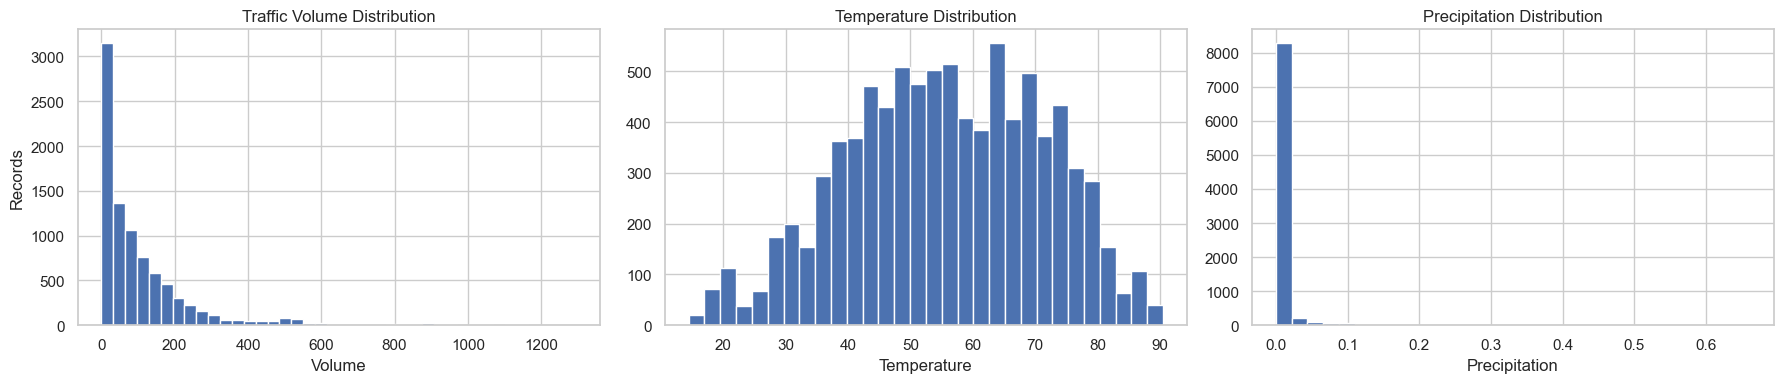

In [165]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

eda_df["vol"].hist(bins=40, ax=axes[0])
axes[0].set_title("Traffic Volume Distribution")
axes[0].set_xlabel("Volume")
axes[0].set_ylabel("Records")

eda_df["temperature_2m"].hist(bins=30, ax=axes[1])
axes[1].set_title("Temperature Distribution")
axes[1].set_xlabel("Temperature")

eda_df["precipitation"].hist(bins=30, ax=axes[2])
axes[2].set_title("Precipitation Distribution")
axes[2].set_xlabel("Precipitation")

plt.tight_layout()
plt.show()

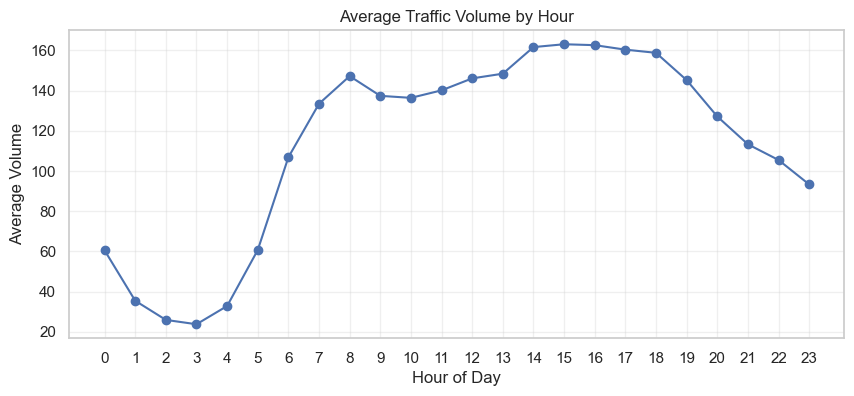

,hour,vol
15,15,163.081232
16,16,162.629526
14,14,161.665738
17,17,160.399433
18,18,158.818713
13,13,148.441489
8,8,147.229111
12,12,146.107612
19,19,145.252226
11,11,140.148936


In [166]:
hourly_pattern = eda_df.groupby("hour", as_index=False)["vol"].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_pattern["hour"], hourly_pattern["vol"], marker="o")
plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Volume")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

display(hourly_pattern.sort_values("vol", ascending=False).head(10))

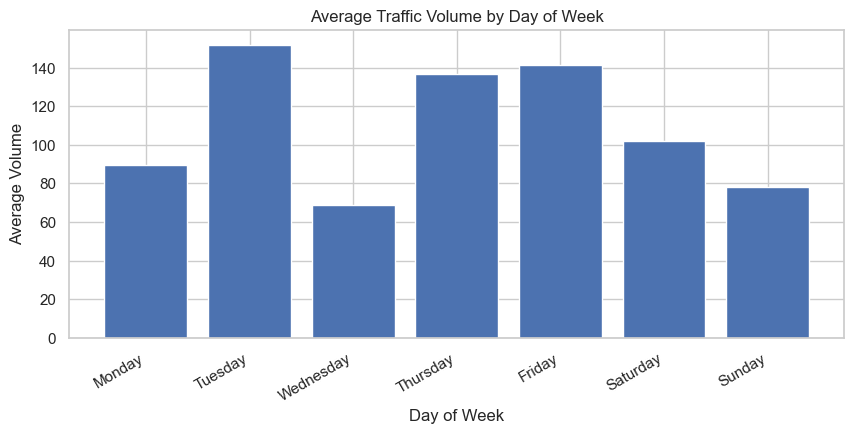

,day_of_week,vol
0,Monday,89.317797
1,Tuesday,151.917834
2,Wednesday,68.658200
3,Thursday,136.588881
4,Friday,141.247605
5,Saturday,102.047809
6,Sunday,78.065217


In [167]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_pattern = eda_df.groupby("day_of_week")["vol"].mean().reindex(day_order).reset_index()

plt.figure(figsize=(10, 4))
plt.bar(day_pattern["day_of_week"], day_pattern["vol"])
plt.title("Average Traffic Volume by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Volume")
plt.xticks(rotation=30, ha="right")
plt.show()

display(day_pattern)

,records,avg_volume,median_volume,max_volume
boro,,,,
Brooklyn,2780,150.629496,79.0,1295
Manhattan,1306,135.843798,127.0,569
Staten Island,315,130.711111,133.0,362
Queens,2586,94.013921,34.0,795
Bronx,1789,61.893236,37.0,263


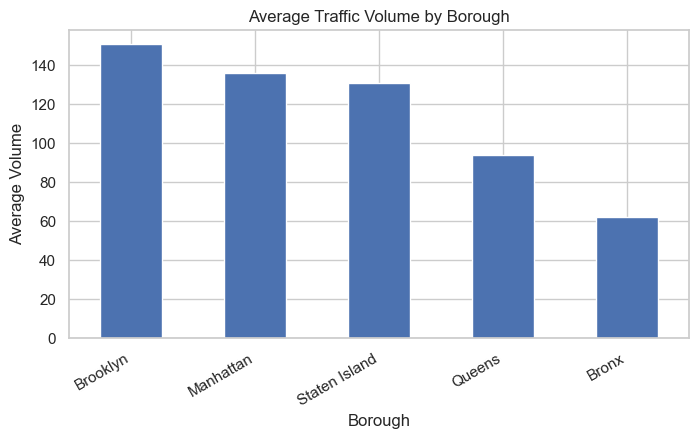

In [168]:
boro_summary = (
    eda_df.groupby("boro")
    .agg(records=("vol", "size"), avg_volume=("vol", "mean"), median_volume=("vol", "median"), max_volume=("vol", "max"))
    .sort_values("avg_volume", ascending=False)
)

display(boro_summary)
boro_summary["avg_volume"].plot(kind="bar", figsize=(8, 4), title="Average Traffic Volume by Borough")
plt.xlabel("Borough")
plt.ylabel("Average Volume")
plt.xticks(rotation=30, ha="right")
plt.show()

In [169]:
street_summary = (
    eda_df.groupby(["boro", "street"])
    .agg(records=("vol", "size"), avg_volume=("vol", "mean"), max_volume=("vol", "max"))
    .query("records >= 5")
    .sort_values("avg_volume", ascending=False)
    .head(15)
)

display(street_summary)

records  avg_volume  max_volume
boro      street                                                           
Brooklyn  BELT PARKWAY                          105  841.133333        1295
          BROOKLYN QUEENS EXPRESSWAY            105  752.076190        1066
Queens    HOOK CREEK BRIDGE                     374  378.390374         682
Manhattan EAST 58 STREET                         23  377.478261         569
Brooklyn  HAMILTON AVENUE                       105  272.180952         740
          GOWANUS EP WB EN HUGH CAREY TNNL      105  270.209524         598
Manhattan AVENUE OF THE AMERICAS                105  263.800000         418
Queens    NORTH CONDUIT AVENUE                   46  252.826087         795
Brooklyn  HAMILTON AVENUE BRIDGE                 71  234.521127         590
          CROPSEY AVENUE                         77  216.740260         371
Queens    BROOKLYN QUEENS EXPRESSWAY             20  215.750000         463
Manhattan 5 AVENUE                              105  214.057143         332
          7 AVENUE                              105  207.676190         309
Bronx     EAST TREMONT AVENUE                    69  183.304348         243
Brooklyn  ATLANTIC AVENUE                       105  178.780952         326

,records,avg_volume,median_volume,avg_temperature,avg_precipitation
is_raining,,,,,
False,7646,113.653675,60.0,55.736092,0.000000
True,1130,108.130088,73.0,54.437401,0.041572


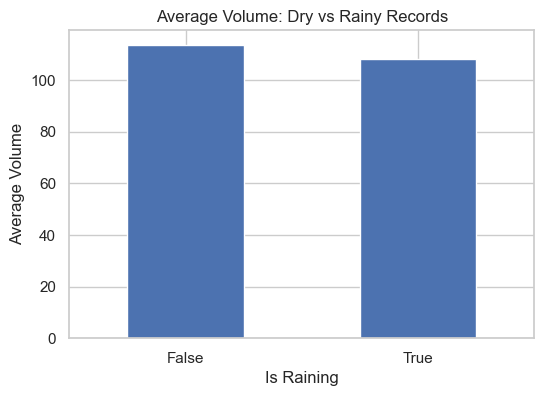

In [170]:
weather_summary = eda_df.groupby("is_raining").agg(
    records=("vol", "size"),
    avg_volume=("vol", "mean"),
    median_volume=("vol", "median"),
    avg_temperature=("temperature_2m", "mean"),
    avg_precipitation=("precipitation", "mean")
)

display(weather_summary)
weather_summary["avg_volume"].plot(kind="bar", figsize=(6, 4), title="Average Volume: Dry vs Rainy Records")
plt.xlabel("Is Raining")
plt.ylabel("Average Volume")
plt.xticks(rotation=0)
plt.show()

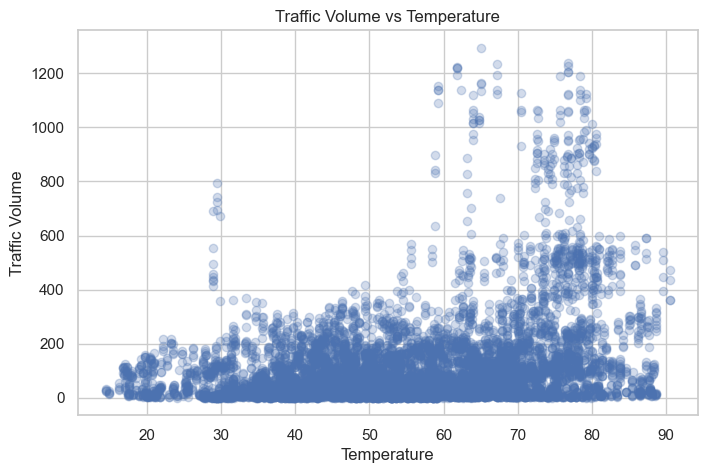

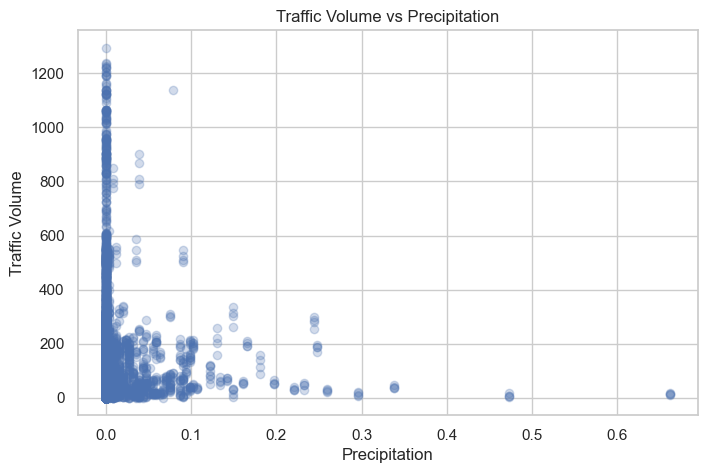

,vol,temperature_2m,precipitation,hour
vol,1.000000,0.303326,-0.022166,0.183205
temperature_2m,0.303326,1.000000,-0.004705,0.194206
precipitation,-0.022166,-0.004705,1.000000,0.000879
hour,0.183205,0.194206,0.000879,1.000000


In [171]:
plt.figure(figsize=(8, 5))
plt.scatter(eda_df["temperature_2m"], eda_df["vol"], alpha=0.25)
plt.title("Traffic Volume vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Traffic Volume")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(eda_df["precipitation"], eda_df["vol"], alpha=0.25)
plt.title("Traffic Volume vs Precipitation")
plt.xlabel("Precipitation")
plt.ylabel("Traffic Volume")
plt.show()

display(eda_df[["vol", "temperature_2m", "precipitation", "hour"]].corr())

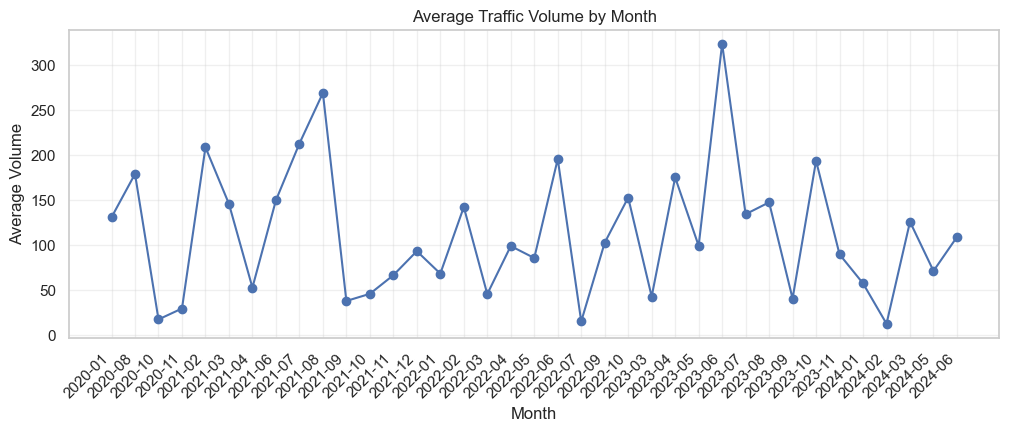

,month,vol
25,2023-05,99.156522
26,2023-06,323.051322
27,2023-07,134.166667
28,2023-08,147.313131
29,2023-09,40.676190
30,2023-10,193.382812
31,2023-11,89.619048
32,2024-01,57.485714
33,2024-02,12.756757
34,2024-03,125.752381


In [172]:
monthly_pattern = eda_df.groupby("month", as_index=False)["vol"].mean()

plt.figure(figsize=(12, 4))
plt.plot(monthly_pattern["month"], monthly_pattern["vol"], marker="o")
plt.title("Average Traffic Volume by Month")
plt.xlabel("Month")
plt.ylabel("Average Volume")
plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.3)
plt.show()

display(monthly_pattern.tail(12))

In [173]:
if "engine" in globals():
    sql_check = pd.read_sql("""
        SELECT
            boro,
            COUNT(*) AS records,
            AVG(vol) AS avg_volume,
            AVG(temperature_2m) AS avg_temperature,
            AVG(precipitation) AS avg_precipitation
        FROM weather_traffic_full
        GROUP BY boro
        ORDER BY avg_volume DESC
    """, con=engine)
    display(sql_check)
else:
    print("MySQL engine is not defined yet. Run the database connection cell first to query from MySQL.")

,boro,records,avg_volume,avg_temperature,avg_precipitation
0,Brooklyn,2780,150.6295,58.024989,0.001684
1,Manhattan,1306,135.8438,51.967320,0.003777
2,Staten Island,315,130.7111,37.370000,0.000550
3,Queens,2586,94.0139,56.877413,0.009798
4,Bronx,1789,61.8932,55.694299,0.006624


### Initial EDA Takeaways

Use the tables and charts above to write your findings. Focus on the busiest hours, borough differences, the busiest streets, whether rainy records have lower or higher traffic volume, and whether temperature or precipitation has a visible relationship with traffic volume.

## 7. ML Pipeline: Weather-Based Rush-Hour Delay Risk

Because the dataset does not include direct travel time or speed, the model predicts a delay-risk proxy based on abnormal traffic volume. It compares a time/location baseline model against a weather-aware model.


### Research Questions

1. Can weather-based predictions help reduce congestion during rush hour?
2. How much does rain and temperature affect traffic delays in NYC?
3. At what weather conditions do NYC traffic delays sharply increase, and can we identify a clear tipping point?

In [174]:
ml_df = eda_df.copy()

import seaborn as sns
sns.set_theme(style="whitegrid")

ml_df["rush_hour"] = ml_df["hour"].between(7, 10) | ml_df["hour"].between(16, 19)
ml_df["rain_intensity"] = pd.cut(
    ml_df["precipitation"],
    bins=[-0.001, 0, 0.05, 0.15, float("inf")],
    labels=["none", "light", "moderate", "heavy"]
)
ml_df["temp_bin"] = pd.cut(
    ml_df["temperature_2m"],
    bins=[-float("inf"), 32, 45, 60, 75, float("inf")],
    labels=["freezing", "cold", "mild", "warm", "hot"]
)

baseline_cols = ["boro", "street", "fromst", "tost", "direction", "day_of_week", "hour"]
baseline_volume = (
    ml_df.groupby(baseline_cols)["vol"]
    .median()
    .reset_index()
    .rename(columns={"vol": "expected_volume"})
)

ml_df = ml_df.merge(baseline_volume, on=baseline_cols, how="left")
ml_df = ml_df[ml_df["expected_volume"] > 0].copy()
ml_df["delay_index"] = ml_df["vol"] / ml_df["expected_volume"]
ml_df["delay_risk"] = (ml_df["delay_index"] >= 1.20).astype(int)

rush_df = ml_df[ml_df["rush_hour"]].copy()

print(f"Rush-hour rows: {len(rush_df):,}")
print(f"Delay-risk rate during rush hour: {rush_df['delay_risk'].mean():.2%}")
display(rush_df[["date", "hour", "boro", "street", "vol", "expected_volume", "delay_index", "delay_risk", "temperature_2m", "precipitation"]].head())

Rush-hour rows: 2,875
Delay-risk rate during rush hour: 9.25%


,date,hour,boro,street,vol,expected_volume,delay_index,delay_risk,temperature_2m,precipitation
41,2023-11-16,7,Brooklyn,AVENUE J,28,37.0,0.756757,0,36.410000,0.0
42,2023-11-16,7,Brooklyn,AVENUE J,43,37.0,1.162162,0,36.410000,0.0
43,2023-11-16,7,Brooklyn,AVENUE J,31,37.0,0.837838,0,36.410000,0.0
44,2023-11-16,7,Brooklyn,AVENUE J,58,37.0,1.567568,1,36.410000,0.0
45,2023-11-16,8,Brooklyn,AVENUE J,41,36.5,1.123288,0,36.049999,0.0


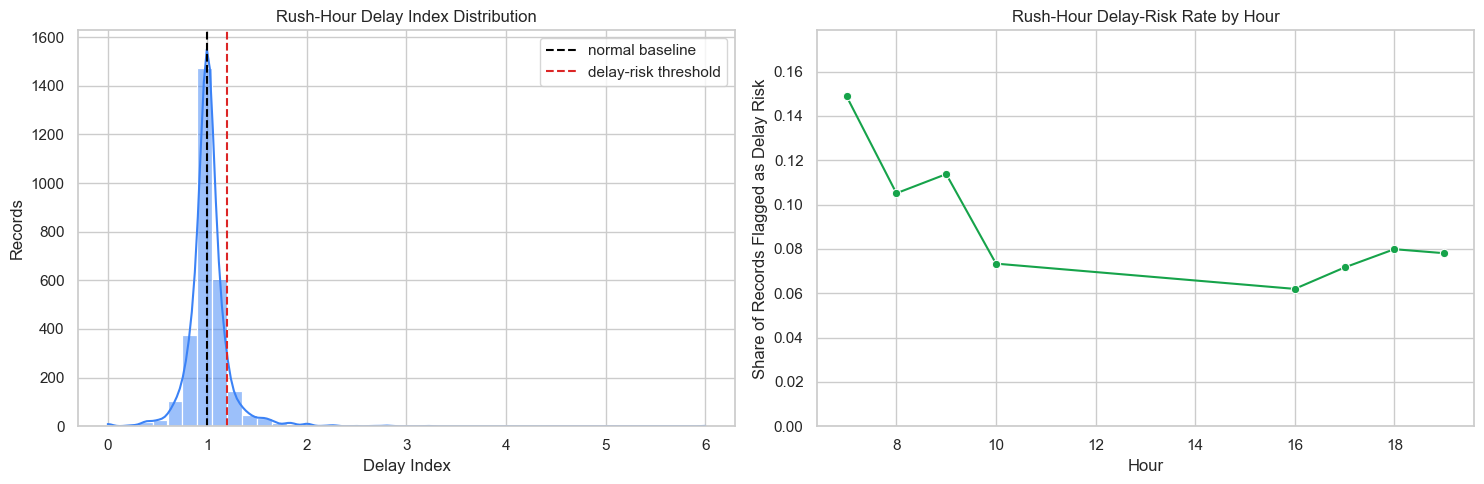

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(rush_df["delay_index"], bins=40, kde=True, ax=axes[0], color="#3b82f6")
axes[0].axvline(1.0, color="black", linestyle="--", label="normal baseline")
axes[0].axvline(1.2, color="#dc2626", linestyle="--", label="delay-risk threshold")
axes[0].set_title("Rush-Hour Delay Index Distribution")
axes[0].set_xlabel("Delay Index")
axes[0].set_ylabel("Records")
axes[0].legend()

hour_delay = rush_df.groupby("hour", as_index=False).agg(
    avg_delay_index=("delay_index", "mean"),
    delay_risk_rate=("delay_risk", "mean")
)
sns.lineplot(data=hour_delay, x="hour", y="delay_risk_rate", marker="o", ax=axes[1], color="#16a34a")
axes[1].set_title("Rush-Hour Delay-Risk Rate by Hour")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Share of Records Flagged as Delay Risk")
axes[1].set_ylim(0, max(0.05, hour_delay["delay_risk_rate"].max() * 1.2))

plt.tight_layout()
plt.show()

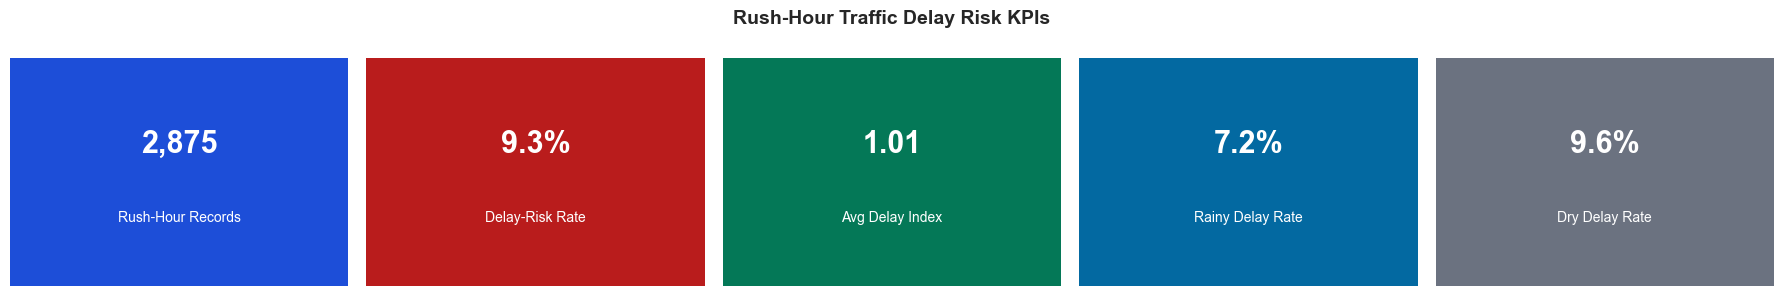

In [176]:
rainy_mask = rush_df["is_raining"].astype(str) == "True"
dry_mask = rush_df["is_raining"].astype(str) == "False"

kpi_values = {
    "Rush-Hour Records": f"{len(rush_df):,}",
    "Delay-Risk Rate": f"{rush_df['delay_risk'].mean():.1%}",
    "Avg Delay Index": f"{rush_df['delay_index'].mean():.2f}",
    "Rainy Delay Rate": f"{rush_df.loc[rainy_mask, 'delay_risk'].mean():.1%}" if rainy_mask.any() else "N/A",
    "Dry Delay Rate": f"{rush_df.loc[dry_mask, 'delay_risk'].mean():.1%}" if dry_mask.any() else "N/A"
}

fig, axes = plt.subplots(1, len(kpi_values), figsize=(18, 3))
card_colors = ["#1d4ed8", "#b91c1c", "#047857", "#0369a1", "#6b7280"]

for ax, (label, value), color in zip(axes, kpi_values.items(), card_colors):
    ax.set_facecolor(color)
    ax.text(0.5, 0.62, value, ha="center", va="center", fontsize=22, color="white", fontweight="bold")
    ax.text(0.5, 0.30, label, ha="center", va="center", fontsize=10, color="white")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle("Rush-Hour Traffic Delay Risk KPIs", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

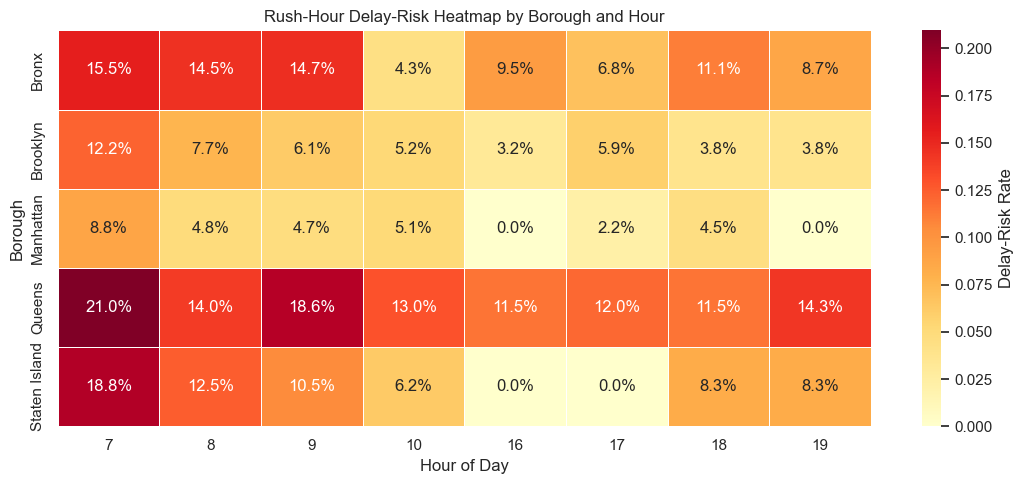

In [177]:
rush_heatmap = rush_df.pivot_table(
    index="boro",
    columns="hour",
    values="delay_risk",
    aggfunc="mean"
)

plt.figure(figsize=(11, 5))
sns.heatmap(
    rush_heatmap,
    annot=True,
    fmt=".1%",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Delay-Risk Rate"}
)
plt.title("Rush-Hour Delay-Risk Heatmap by Borough and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Borough")
plt.tight_layout()
plt.show()

In [178]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

baseline_features = ["hour", "boro", "street", "direction", "day_of_week"]
weather_features = baseline_features + ["temperature_2m", "precipitation", "is_raining", "rain_intensity", "temp_bin"]
target = "delay_risk"

categorical_cleanup_cols = ["boro", "street", "direction", "day_of_week", "is_raining", "rain_intensity", "temp_bin"]
for col in categorical_cleanup_cols:
    rush_df[col] = rush_df[col].astype("object").where(rush_df[col].notna(), "missing").astype(str)

def build_model(feature_cols):
    numeric_features = [col for col in feature_cols if col in ["hour", "temperature_2m", "precipitation"]]
    categorical_features = [col for col in feature_cols if col not in numeric_features]

    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ])

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=42, class_weight="balanced"))
    ])

X_train, X_test, y_train, y_test = train_test_split(
    rush_df[weather_features],
    rush_df[target],
    test_size=0.25,
    random_state=42,
    stratify=rush_df[target]
)

baseline_model = build_model(baseline_features)
weather_model = build_model(weather_features)

baseline_model.fit(X_train[baseline_features], y_train)
weather_model.fit(X_train[weather_features], y_train)

def evaluate_model(name, model, feature_cols):
    pred = model.predict(X_test[feature_cols])
    proba = model.predict_proba(X_test[feature_cols])[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba)
    }

model_results = pd.DataFrame([
    evaluate_model("baseline_time_location", baseline_model, baseline_features),
    evaluate_model("weather_aware", weather_model, weather_features)
])

display(model_results)
print("Weather model confusion matrix:")
display(pd.DataFrame(confusion_matrix(y_test, weather_model.predict(X_test[weather_features])), index=["actual_normal", "actual_delay"], columns=["pred_normal", "pred_delay"]))
print(classification_report(y_test, weather_model.predict(X_test[weather_features]), zero_division=0))

,model,accuracy,precision,recall,f1,roc_auc
0,baseline_time_location,0.764951,0.140845,0.298507,0.191388,0.683843
1,weather_aware,0.780250,0.147287,0.283582,0.193878,0.685342


Weather model confusion matrix:


,pred_normal,pred_delay
actual_normal,542,110
actual_delay,48,19


              precision    recall  f1-score   support

           0       0.92      0.83      0.87       652
           1       0.15      0.28      0.19        67

    accuracy                           0.78       719
   macro avg       0.53      0.56      0.53       719
weighted avg       0.85      0.78      0.81       719



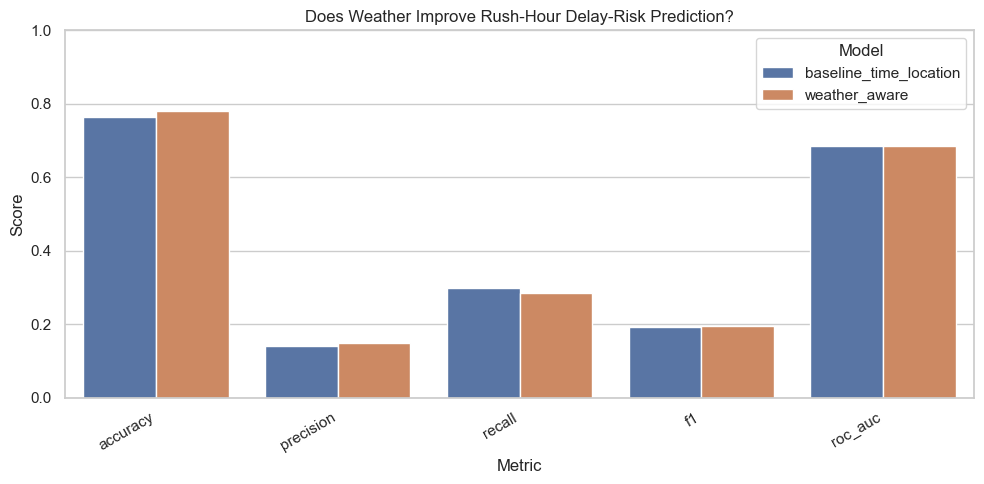

,weather_model_lift
accuracy,0.015299
precision,0.006442
recall,-0.014925
f1,0.002490
roc_auc,0.001499


In [179]:
model_results_long = model_results.melt(id_vars="model", var_name="metric", value_name="score")

plt.figure(figsize=(10, 5))
sns.barplot(data=model_results_long, x="metric", y="score", hue="model")
plt.title("Does Weather Improve Rush-Hour Delay-Risk Prediction?")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

weather_lift = model_results.set_index("model").loc["weather_aware"] - model_results.set_index("model").loc["baseline_time_location"]
display(weather_lift.to_frame("weather_model_lift"))

In [180]:
feature_names = weather_model.named_steps["preprocessor"].get_feature_names_out()
importances = weather_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

display(importance_df.head(20))

weather_importance = importance_df[importance_df["feature"].str.contains("temperature_2m|precipitation|is_raining|rain_intensity|temp_bin", regex=True)]
print(f"Combined weather feature importance: {weather_importance['importance'].sum():.3f}")
display(weather_importance)

,feature,importance
1,num__temperature_2m,0.162639
0,num__hour,0.128669
6,cat__boro_Queens,0.037541
79,cat__direction_WB,0.030102
76,cat__direction_EB,0.023988
2,num__precipitation,0.023775
80,cat__day_of_week_Friday,0.022975
37,cat__street_CODY AVENUE,0.022746
56,cat__street_HOOK CREEK BRIDGE,0.022060
5,cat__boro_Manhattan,0.021655


Combined weather feature importance: 0.291


,feature,importance
1,num__temperature_2m,0.162639
2,num__precipitation,0.023775
96,cat__temp_bin_mild,0.016932
97,cat__temp_bin_warm,0.016808
93,cat__temp_bin_cold,0.012598
95,cat__temp_bin_hot,0.011867
90,cat__rain_intensity_light,0.009716
88,cat__is_raining_True,0.009281
92,cat__rain_intensity_none,0.009257
87,cat__is_raining_False,0.008465


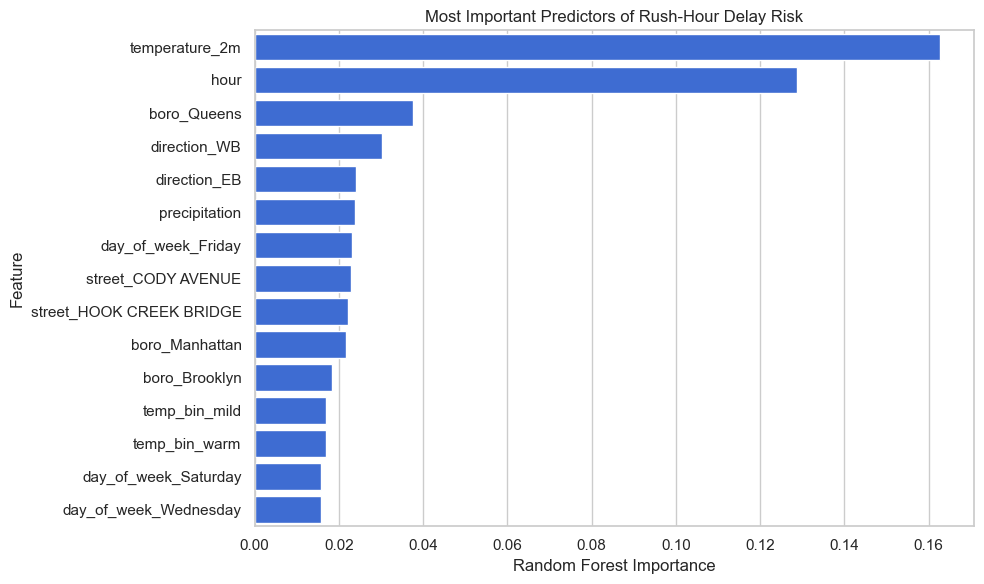

In [181]:
top_importance = importance_df.head(15).copy()
top_importance["feature"] = top_importance["feature"].str.replace("num__", "", regex=False).str.replace("cat__", "", regex=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_importance, x="importance", y="feature", color="#2563eb")
plt.title("Most Important Predictors of Rush-Hour Delay Risk")
plt.xlabel("Random Forest Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [182]:
weather_effects = rush_df.groupby(["rain_intensity", "temp_bin"], observed=True).agg(
    records=("delay_risk", "size"),
    avg_delay_index=("delay_index", "mean"),
    delay_risk_rate=("delay_risk", "mean"),
    avg_volume=("vol", "mean")
).reset_index().sort_values("delay_risk_rate", ascending=False)

display(weather_effects)

rain_effect = rush_df.groupby("rain_intensity", observed=True).agg(
    records=("delay_risk", "size"),
    avg_delay_index=("delay_index", "mean"),
    delay_risk_rate=("delay_risk", "mean")
).reset_index()

temp_effect = rush_df.groupby("temp_bin", observed=True).agg(
    records=("delay_risk", "size"),
    avg_delay_index=("delay_index", "mean"),
    delay_risk_rate=("delay_risk", "mean")
).reset_index()

display(rain_effect)
display(temp_effect)

,rain_intensity,temp_bin,records,avg_delay_index,delay_risk_rate,avg_volume
0,heavy,mild,4,1.048387,0.250000,32.500000
9,moderate,mild,41,0.987022,0.146341,59.487805
12,none,freezing,219,1.025553,0.132420,105.036530
11,none,cold,437,1.017260,0.130435,104.839817
10,moderate,warm,20,1.021471,0.100000,162.550000
15,none,warm,711,1.011644,0.092827,156.465541
14,none,mild,668,1.007218,0.092814,113.302395
2,light,cold,68,1.015092,0.088235,79.544118
5,light,mild,174,1.019050,0.068966,117.448276
13,none,hot,412,1.006425,0.050971,288.565534


,rain_intensity,records,avg_delay_index,delay_risk_rate
0,heavy,8,1.018194,0.125000
1,light,347,1.016269,0.063401
2,moderate,73,0.996455,0.109589
3,none,2447,1.011805,0.096036


,temp_bin,records,avg_delay_index,delay_risk_rate
0,cold,513,1.016330,0.122807
1,freezing,224,1.025236,0.129464
2,hot,428,1.006586,0.049065
3,mild,887,1.008791,0.091319
4,warm,823,1.011873,0.087485


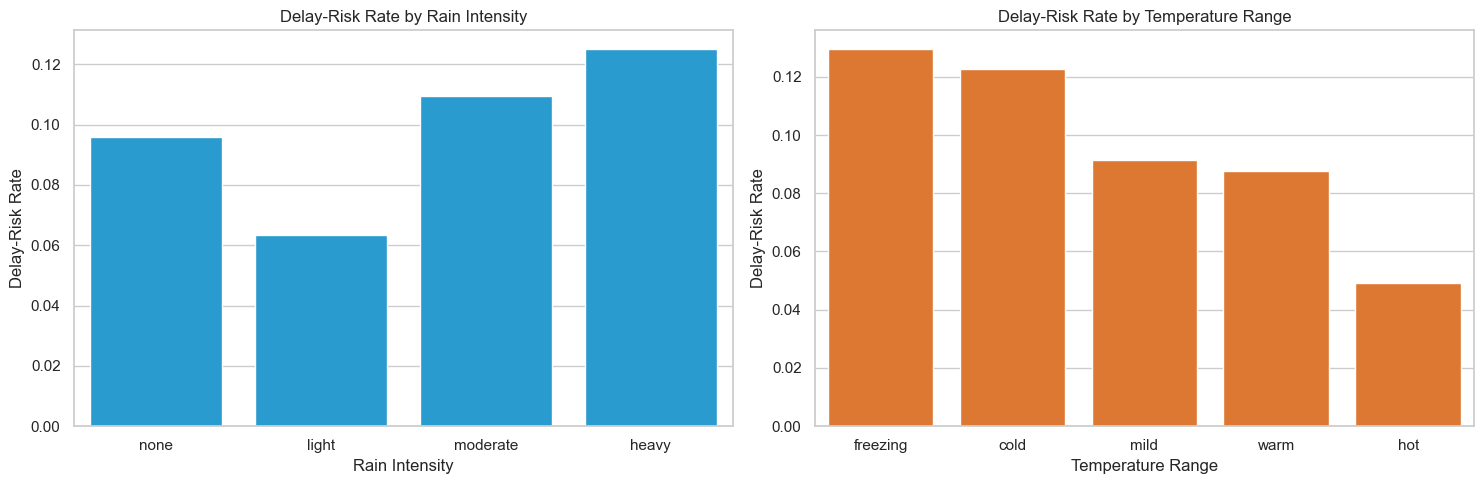

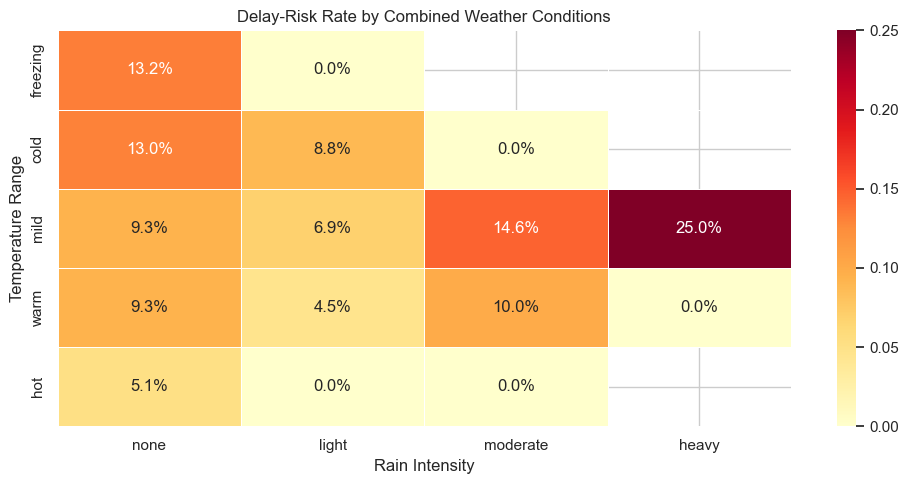

In [183]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

rain_order = ["none", "light", "moderate", "heavy"]
sns.barplot(data=rain_effect, x="rain_intensity", y="delay_risk_rate", order=rain_order, ax=axes[0], color="#0ea5e9")
axes[0].set_title("Delay-Risk Rate by Rain Intensity")
axes[0].set_xlabel("Rain Intensity")
axes[0].set_ylabel("Delay-Risk Rate")

temp_order = ["freezing", "cold", "mild", "warm", "hot"]
sns.barplot(data=temp_effect, x="temp_bin", y="delay_risk_rate", order=temp_order, ax=axes[1], color="#f97316")
axes[1].set_title("Delay-Risk Rate by Temperature Range")
axes[1].set_xlabel("Temperature Range")
axes[1].set_ylabel("Delay-Risk Rate")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.heatmap(
    weather_effects.pivot(index="temp_bin", columns="rain_intensity", values="delay_risk_rate").reindex(index=temp_order, columns=rain_order),
    annot=True,
    fmt=".1%",
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Delay-Risk Rate by Combined Weather Conditions")
plt.xlabel("Rain Intensity")
plt.ylabel("Temperature Range")
plt.tight_layout()
plt.show()

In [184]:
rush_scored = rush_df.copy()
rush_scored["predicted_delay_probability"] = weather_model.predict_proba(rush_scored[weather_features])[:, 1]

precip_thresholds = sorted(rush_scored["precipitation"].dropna().unique())
precip_thresholds = [x for x in precip_thresholds if x > 0]

threshold_rows = []
for threshold in precip_thresholds:
    lower = rush_scored[rush_scored["precipitation"] < threshold]
    upper = rush_scored[rush_scored["precipitation"] >= threshold]
    if len(lower) >= 100 and len(upper) >= 100:
        threshold_rows.append({
            "precipitation_threshold": threshold,
            "below_delay_probability": lower["predicted_delay_probability"].mean(),
            "above_delay_probability": upper["predicted_delay_probability"].mean(),
            "probability_jump": upper["predicted_delay_probability"].mean() - lower["predicted_delay_probability"].mean(),
            "below_records": len(lower),
            "above_records": len(upper)
        })

precip_tipping = pd.DataFrame(threshold_rows).sort_values("probability_jump", ascending=False)
display(precip_tipping.head(10))

temp_thresholds = range(int(rush_scored["temperature_2m"].min()) + 1, int(rush_scored["temperature_2m"].max()))
temp_rows = []
for threshold in temp_thresholds:
    lower = rush_scored[rush_scored["temperature_2m"] < threshold]
    upper = rush_scored[rush_scored["temperature_2m"] >= threshold]
    if len(lower) >= 100 and len(upper) >= 100:
        temp_rows.append({
            "temperature_threshold": threshold,
            "below_delay_probability": lower["predicted_delay_probability"].mean(),
            "above_delay_probability": upper["predicted_delay_probability"].mean(),
            "absolute_probability_jump": abs(upper["predicted_delay_probability"].mean() - lower["predicted_delay_probability"].mean()),
            "direction": "higher_temp_more_delay" if upper["predicted_delay_probability"].mean() > lower["predicted_delay_probability"].mean() else "lower_temp_more_delay",
            "below_records": len(lower),
            "above_records": len(upper)
        })

temp_tipping = pd.DataFrame(temp_rows).sort_values("absolute_probability_jump", ascending=False)
display(temp_tipping.head(10))

,precipitation_threshold,below_delay_probability,above_delay_probability,probability_jump,below_records,above_records
9,0.039370,0.253993,0.263349,0.009356,2762,113
8,0.035433,0.254914,0.242289,-0.012625,2749,126
7,0.031496,0.255765,0.227340,-0.028425,2733,142
6,0.027559,0.256515,0.220296,-0.036220,2704,171
1,0.007874,0.260342,0.210931,-0.049411,2527,348
5,0.023622,0.257559,0.207319,-0.050240,2692,183
3,0.015748,0.259026,0.203603,-0.055423,2633,242
4,0.019685,0.258526,0.200674,-0.057852,2668,207
2,0.011811,0.261128,0.190635,-0.070493,2599,276
0,0.003937,0.266325,0.185961,-0.080364,2447,428


,temperature_threshold,below_delay_probability,above_delay_probability,absolute_probability_jump,direction,below_records,above_records
13,40,0.369256,0.230814,0.138442,lower_temp_more_delay,489,2386
14,41,0.365232,0.229650,0.135583,lower_temp_more_delay,524,2351
11,38,0.369861,0.235368,0.134492,lower_temp_more_delay,406,2469
12,39,0.367055,0.234107,0.132948,lower_temp_more_delay,438,2437
10,37,0.365379,0.237759,0.127620,lower_temp_more_delay,374,2501
15,42,0.350455,0.230076,0.120379,lower_temp_more_delay,580,2295
16,43,0.347288,0.227965,0.119324,lower_temp_more_delay,636,2239
9,36,0.355823,0.240798,0.115025,lower_temp_more_delay,339,2536
18,45,0.339121,0.225143,0.113977,lower_temp_more_delay,737,2138
17,44,0.340646,0.227424,0.113221,lower_temp_more_delay,684,2191


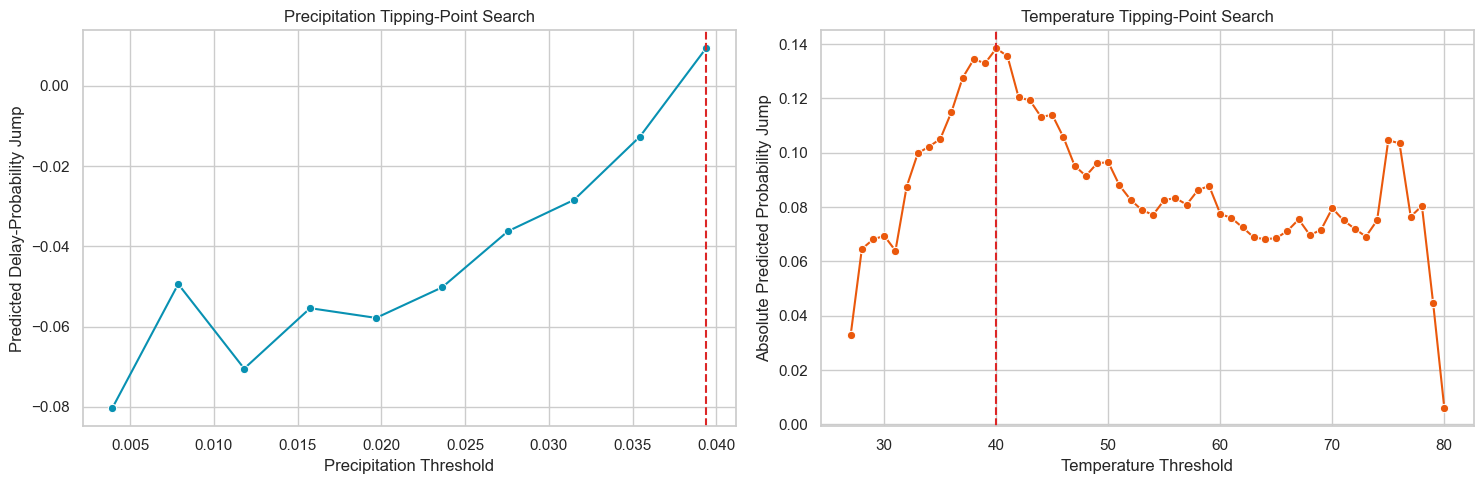

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

if len(precip_tipping):
    precip_plot = precip_tipping.sort_values("precipitation_threshold")
    sns.lineplot(data=precip_plot, x="precipitation_threshold", y="probability_jump", marker="o", ax=axes[0], color="#0891b2")
    best_precip = precip_tipping.iloc[0]
    axes[0].axvline(best_precip["precipitation_threshold"], color="#dc2626", linestyle="--")
    axes[0].set_title("Precipitation Tipping-Point Search")
    axes[0].set_xlabel("Precipitation Threshold")
    axes[0].set_ylabel("Predicted Delay-Probability Jump")
else:
    axes[0].text(0.5, 0.5, "No reliable precipitation tipping point", ha="center", va="center")
    axes[0].set_axis_off()

if len(temp_tipping):
    temp_plot = temp_tipping.sort_values("temperature_threshold")
    sns.lineplot(data=temp_plot, x="temperature_threshold", y="absolute_probability_jump", marker="o", ax=axes[1], color="#ea580c")
    best_temp = temp_tipping.iloc[0]
    axes[1].axvline(best_temp["temperature_threshold"], color="#dc2626", linestyle="--")
    axes[1].set_title("Temperature Tipping-Point Search")
    axes[1].set_xlabel("Temperature Threshold")
    axes[1].set_ylabel("Absolute Predicted Probability Jump")
else:
    axes[1].text(0.5, 0.5, "No reliable temperature tipping point", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

In [186]:
weather_auc_lift = model_results.loc[model_results["model"] == "weather_aware", "roc_auc"].iloc[0] - model_results.loc[model_results["model"] == "baseline_time_location", "roc_auc"].iloc[0]
weather_f1_lift = model_results.loc[model_results["model"] == "weather_aware", "f1"].iloc[0] - model_results.loc[model_results["model"] == "baseline_time_location", "f1"].iloc[0]

best_precip_threshold = precip_tipping.iloc[0] if len(precip_tipping) else None
best_temp_threshold = temp_tipping.iloc[0] if len(temp_tipping) else None

print("Q1: Can weather-based predictions help reduce congestion during rush hour?")
print(f"Weather-aware model ROC-AUC lift vs baseline: {weather_auc_lift:.3f}")
print(f"Weather-aware model F1 lift vs baseline: {weather_f1_lift:.3f}")
print("If these lifts are positive, weather adds predictive value beyond time and location.")

print("\nQ2: How much does rain and temperature affect traffic delay risk?")
print(f"Combined weather feature importance: {weather_importance['importance'].sum():.3f}")
display(rain_effect)
display(temp_effect)

print("\nQ3: At what weather conditions do delay risks sharply increase?")
if best_precip_threshold is not None:
    print(f"Strongest precipitation tipping candidate: >= {best_precip_threshold['precipitation_threshold']:.3f}, probability jump {best_precip_threshold['probability_jump']:.3f}")
else:
    print("No reliable precipitation tipping point found with enough records on both sides.")

if best_temp_threshold is not None:
    print(f"Strongest temperature tipping candidate: {best_temp_threshold['temperature_threshold']:.0f} degrees, jump {best_temp_threshold['absolute_probability_jump']:.3f}, direction: {best_temp_threshold['direction']}")
else:
    print("No reliable temperature tipping point found with enough records on both sides.")

Q1: Can weather-based predictions help reduce congestion during rush hour?
Weather-aware model ROC-AUC lift vs baseline: 0.001
Weather-aware model F1 lift vs baseline: 0.002
If these lifts are positive, weather adds predictive value beyond time and location.

Q2: How much does rain and temperature affect traffic delay risk?
Combined weather feature importance: 0.291


,rain_intensity,records,avg_delay_index,delay_risk_rate
0,heavy,8,1.018194,0.125000
1,light,347,1.016269,0.063401
2,moderate,73,0.996455,0.109589
3,none,2447,1.011805,0.096036


,temp_bin,records,avg_delay_index,delay_risk_rate
0,cold,513,1.016330,0.122807
1,freezing,224,1.025236,0.129464
2,hot,428,1.006586,0.049065
3,mild,887,1.008791,0.091319
4,warm,823,1.011873,0.087485



Q3: At what weather conditions do delay risks sharply increase?
Strongest precipitation tipping candidate: >= 0.039, probability jump 0.009
Strongest temperature tipping candidate: 40 degrees, jump 0.138, direction: lower_temp_more_delay


### Suggested Interpretation

Use `model_results` to answer whether weather improves rush-hour prediction. Use the feature-importance table and grouped rain/temperature summaries to explain how rain and temperature affect delay risk. Use `precip_tipping` and `temp_tipping` to identify the strongest weather thresholds where predicted delay risk changes sharply.

## 8. Tableau Dashboard Tables

Create MySQL tables designed for the Tableau dashboards: live traffic predictions, city weather comparison, and A/B model results.


In [187]:
from tableau_exports import build_tableau_tables, write_tableau_tables

tableau_tables = build_tableau_tables(
    rush_df=rush_df,
    rush_scored=rush_scored,
    model_results=model_results,
    weather_features=weather_features,
    weather_model=weather_model
)

for table_name, table_df in tableau_tables.items():
    print(f"{table_name}: {table_df.shape[0]:,} rows x {table_df.shape[1]:,} columns")

if "engine" in globals():
    written_tables = write_tableau_tables(engine, tableau_tables)
    print("Written to MySQL:")
    for table_name in written_tables:
        print(f"- {table_name}")
else:
    print("MySQL engine is not defined. Run the database connection cell before writing Tableau tables.")

tableau_ml_predictions_detail: 2,875 rows x 20 columns
tableau_live_predictions_by_borough: 5 rows x 10 columns
tableau_weather_delay_summary: 79 rows x 10 columns
tableau_model_results: 4 rows x 11 columns
tableau_today_weather_predictions: 5 rows x 14 columns
Written to MySQL:
- tableau_ml_predictions_detail
- tableau_live_predictions_by_borough
- tableau_weather_delay_summary
- tableau_model_results
- tableau_today_weather_predictions
